<a href="https://colab.research.google.com/github/Fatou-Kine3/github_task/blob/main/ResNet_and_VGG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
## Problem 1

In [2]:
import tensorflow as tf
from keras.applications import ResNet50, VGG16
from keras.applications.resnet50 import preprocess_input as resnet_preprocess
from keras.applications.vgg16 import preprocess_input as vgg_preprocess
from keras.layers import (Input, Conv2D, MaxPooling2D, Conv2DTranspose,
                         concatenate, BatchNormalization, Activation, Lambda)
from keras.models import Model
from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.optimizers import Adam
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {tf.keras.__version__}")

TensorFlow version: 2.20.0
Keras version: 3.13.2


In [3]:
# Create ResNet50 backbone
def create_resnet50_encoder(input_shape=(128, 128, 3)):
    """Create ResNet50 encoder with pretrained weights."""
    base_model = ResNet50(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape,
        pooling=None
    )
    return base_model

# Create the model and verify layer names
input_shape = (128, 128, 3)
base_model = create_resnet50_encoder(input_shape)

# Verify actual layer names and shapes - FIXED
print("ResNet50 Layer Names and Output Shapes:")
print("-" * 60)
for layer in base_model.layers:
    try:
        # Try to get output shape
        if hasattr(layer, 'output_shape'):
            shape = layer.output_shape
        elif hasattr(layer, 'output'):
            shape = layer.output.shape
        else:
            shape = "No output shape"
        print(f"{layer.name:30} {shape}")
    except Exception as e:
        print(f"{layer.name:30} Error: {e}")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
ResNet50 Layer Names and Output Shapes:
------------------------------------------------------------
input_layer                    (None, 128, 128, 3)
conv1_pad                      (None, 134, 134, 3)
conv1_conv                     (None, 64, 64, 64)
conv1_bn                       (None, 64, 64, 64)
conv1_relu                     (None, 64, 64, 64)
pool1_pad                      (None, 66, 66, 64)
pool1_pool                     (None, 32, 32, 64)
conv2_block1_1_conv            (None, 32, 32, 64)
conv2_block1_1_bn              (None, 32, 32, 64)
conv2_block1_1_relu            (None, 32, 32, 64)
conv2_block1_2_conv            (None, 32, 32, 64)
conv2_block1_2_bn              (None, 32, 32, 64)
conv2_block1_2_relu            (None, 32, 32, 64)
conv2_block1_0_conv            (None, 32, 32, 256)
conv2_block1_3_conv            (None, 32, 32, 256)
conv2_block1_0_bn              (None, 32, 32, 256)
conv2_block1_3_bn              (None, 32, 3

In [4]:
def convert_to_3channel(images):
    """
    Convert grayscale images to 3-channel format for pretrained encoders.
    Method: Replicate the single channel across 3 identical channels.
    """
    # images shape: (batch, height, width, 1)
    if len(images.shape) == 4 and images.shape[-1] == 1:
        return tf.repeat(images, 3, axis=-1)
    elif len(images.shape) == 3:  # Single image without batch dimension
        return tf.stack([images, images, images], axis=-1)
    else:
        return images
    # Output shape: (batch, height, width, 3)

# Test the conversion
test_image = tf.random.normal((1, 128, 128, 1))
converted = convert_to_3channel(test_image)
print(f"Input shape: {test_image.shape}")
print(f"Converted shape: {converted.shape}")

Input shape: (1, 128, 128, 1)
Converted shape: (1, 128, 128, 3)


In [5]:
def identify_resnet50_skip_layers(base_model):
    """
    Identify ResNet50 intermediate feature maps for skip connections.
    Returns the actual layer names and output shapes.
    """
    skip_info = {}

    # Key skip connection layers in ResNet50
    potential_skip_layers = [
        'conv1_relu',      # Early feature maps
        'conv2_block3_out', # After first residual block
        'conv3_block4_out', # After second residual block
        'conv4_block6_out', # After third residual block
        'conv5_block3_out'  # Bottleneck/top
    ]

    print("\nResNet50 Skip Connection Options:")
    print("-" * 70)
    print(f"{'Layer Name':<25} {'Output Shape':<30} {'Spatial Size'}")
    print("-" * 70)

    for layer_name in potential_skip_layers:
        try:
            layer = base_model.get_layer(layer_name)
            # Get output shape safely
            if hasattr(layer, 'output_shape'):
                shape = layer.output_shape
            elif hasattr(layer, 'output'):
                shape = layer.output.shape
            else:
                shape = "Unknown"

            spatial_size = shape[1] if isinstance(shape, (tuple, list)) and len(shape) > 2 else 'N/A'
            print(f"{layer_name:<25} {str(shape):<30} {spatial_size}")
            skip_info[layer_name] = shape
        except ValueError:
            print(f"{layer_name:<25} {'NOT FOUND':<30}")
        except Exception as e:
            print(f"{layer_name:<25} Error: {str(e)[:30]}")

    return skip_info

# Identify skip layers
skip_info = identify_resnet50_skip_layers(base_model)


ResNet50 Skip Connection Options:
----------------------------------------------------------------------
Layer Name                Output Shape                   Spatial Size
----------------------------------------------------------------------
conv1_relu                (None, 64, 64, 64)             64
conv2_block3_out          (None, 32, 32, 256)            32
conv3_block4_out          (None, 16, 16, 512)            16
conv4_block6_out          (None, 8, 8, 1024)             8
conv5_block3_out          (None, 4, 4, 2048)             4


In [6]:
def build_resnet50_unet(input_shape=(128, 128, 1)):
    """
    Build U-Net with ResNet50 encoder.
    """
    # Input: single channel grayscale
    inputs = Input(shape=input_shape)

    # Convert to 3 channels (replication method)
    x = Lambda(lambda img: tf.repeat(img, 3, axis=-1))(inputs)

    # Apply ResNet50 preprocessing
    x = Lambda(lambda img: resnet_preprocess(img))(x)

    # Create ResNet50 backbone
    base_model = ResNet50(
        include_top=False,
        weights='imagenet',
        input_tensor=x,
        input_shape=(input_shape[0], input_shape[1], 3)
    )

    # Extract skip connections (verified layer names)
    skip_features = {}

    # Try to get each skip connection
    skip_names = ['conv1_relu', 'conv2_block3_out', 'conv3_block4_out', 'conv4_block6_out']
    for name in skip_names:
        try:
            skip_features[name] = base_model.get_layer(name).output
            print(f"✓ Found skip layer: {name}")
        except ValueError:
            print(f"✗ Skip layer not found: {name}")
            # Fallback: try to find similar layers
            for layer in base_model.layers:
                if name.replace('_relu', '') in layer.name or name.replace('_out', '') in layer.name:
                    skip_features[name] = layer.output
                    print(f"  → Using fallback: {layer.name}")
                    break

    # Top/bottleneck layer - try conv5_block3_out
    try:
        top = base_model.get_layer('conv5_block3_out').output
        print(f"✓ Found top layer: conv5_block3_out")
    except ValueError:
        # Fallback to last layer
        top = base_model.layers[-1].output
        print(f"✗ Using last layer as top: {base_model.layers[-1].name}")

    # --- Decoder Path ---

    # We need to ensure spatial dimensions match for concatenation
    # ResNet50 typical output sizes for 128x128 input:
    # conv1_relu: 64x64
    # conv2_block3_out: 32x32
    # conv3_block4_out: 16x16
    # conv4_block6_out: 8x8
    # conv5_block3_out: 4x4

    # Decoder level 1: 4x4 -> 8x8
    d1 = Conv2DTranspose(512, (3,3), strides=(2,2), padding='same')(top)
    if 'conv4_block6_out' in skip_features:
        d1 = concatenate([d1, skip_features['conv4_block6_out']])  # Match at 8x8
    d1 = conv_block(d1, 512)

    # Decoder level 2: 8x8 -> 16x16
    d2 = Conv2DTranspose(256, (3,3), strides=(2,2), padding='same')(d1)
    if 'conv3_block4_out' in skip_features:
        d2 = concatenate([d2, skip_features['conv3_block4_out']])  # Match at 16x16
    d2 = conv_block(d2, 256)

    # Decoder level 3: 16x16 -> 32x32
    d3 = Conv2DTranspose(128, (3,3), strides=(2,2), padding='same')(d2)
    if 'conv2_block3_out' in skip_features:
        d3 = concatenate([d3, skip_features['conv2_block3_out']])  # Match at 32x32
    d3 = conv_block(d3, 128)

    # Decoder level 4: 32x32 -> 64x64
    d4 = Conv2DTranspose(64, (3,3), strides=(2,2), padding='same')(d3)
    if 'conv1_relu' in skip_features:
        d4 = concatenate([d4, skip_features['conv1_relu']])  # Match at 64x64
    d4 = conv_block(d4, 64)

    # Final upsample to original size: 64x64 -> 128x128
    d5 = Conv2DTranspose(32, (3,3), strides=(2,2), padding='same')(d4)

    # Output layer: binary segmentation mask
    outputs = Conv2D(1, (1,1), activation='sigmoid')(d5)

    model = Model(inputs=inputs, outputs=outputs)
    return model, base_model, skip_features

def conv_block(x, filters):
    """Standard conv block with batch norm and ReLU."""
    x = Conv2D(filters, (3,3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    return x

# Build the model
print("\nBuilding ResNet50 U-Net...")
resnet_model, resnet_backbone, skip_features = build_resnet50_unet((128, 128, 1))
print("\nModel built successfully!")
resnet_model.summary()


Building ResNet50 U-Net...
✓ Found skip layer: conv1_relu
✓ Found skip layer: conv2_block3_out
✓ Found skip layer: conv3_block4_out
✓ Found skip layer: conv4_block6_out
✓ Found top layer: conv5_block3_out

Model built successfully!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 128, 128,  │          0 │ input_layer_1[0]… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 128, 128,  │          0 │ lambda[0][0]      │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ lambda_1[0][0]    │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r

 Total params: 43,960,897 (167.70 MB)

 Trainable params: 43,905,857 (167.49 MB)

 Non-trainable params: 55,040 (215.00 KB)

In [7]:
def setup_resnet50_training(model, base_model, freeze_encoder=True):
    """
    Configure which layers are trainable during training.
    """
    if freeze_encoder:
        # Freeze all encoder layers
        base_model.trainable = False
        print("All ResNet50 encoder layers are FROZEN")
    else:
        base_model.trainable = True
        print("All ResNet50 encoder layers are TRAINABLE")

    # Verify trainable status
    print("\nTrainable layer summary:")
    print("-" * 60)
    trainable_count = 0
    frozen_count = 0
    total_layers = 0

    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):  # This is the backbone
            for sublayer in layer.layers:
                total_layers += 1
                if sublayer.trainable:
                    trainable_count += 1
                else:
                    frozen_count += 1

    print(f"Total layers in backbone: {total_layers}")
    print(f"Trainable layers: {trainable_count}")
    print(f"Frozen layers: {frozen_count}")

    return model

# Setup training configuration
resnet_model, resnet_backbone, _ = build_resnet50_unet((128, 128, 1))
resnet_model = setup_resnet50_training(resnet_model, resnet_backbone, freeze_encoder=True)

✓ Found skip layer: conv1_relu
✓ Found skip layer: conv2_block3_out
✓ Found skip layer: conv3_block4_out
✓ Found skip layer: conv4_block6_out
✓ Found top layer: conv5_block3_out
All ResNet50 encoder layers are FROZEN

Trainable layer summary:
------------------------------------------------------------
Total layers in backbone: 0
Trainable layers: 0
Frozen layers: 0


In [8]:
def foreground_iou(y_true, y_pred):
    """Mean Intersection over Union for foreground class."""
    # Threshold predictions
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    # Flatten tensors
    y_true_flat = tf.reshape(y_true, [-1])
    y_pred_flat = tf.reshape(y_pred, [-1])

    # Calculate IoU
    intersection = tf.reduce_sum(y_true_flat * y_pred_flat)
    union = tf.reduce_sum(y_true_flat) + tf.reduce_sum(y_pred_flat) - intersection

    # Avoid division by zero
    iou = intersection / (union + tf.keras.backend.epsilon())
    return iou

def configure_training(model, learning_rate=1e-3):
    """Configure model for training."""
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', foreground_iou]
    )
    return model

# Configure the model
resnet_model = configure_training(resnet_model, learning_rate=1e-3)

# Setup callbacks
checkpoint = ModelCheckpoint(
    'resnet50_best_model.keras',
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

callbacks = [checkpoint, early_stopping]

print("\nModel configured for training:")
print(f"Loss: binary_crossentropy")
print(f"Metrics: accuracy, foreground_iou")
print(f"Checkpoint: resnet50_best_model.keras")
print(f"Early stopping patience: 10 epochs")


Model configured for training:
Loss: binary_crossentropy
Metrics: accuracy, foreground_iou
Checkpoint: resnet50_best_model.keras
Early stopping patience: 10 epochs


In [9]:
def verify_skip_connections(model):
    """Verify that all skip connections have matching spatial dimensions."""
    print("\nVerifying Skip Connection Shapes:")
    print("-" * 70)

    # Get the internal layers
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):  # This is the backbone
            skip_layers = ['conv1_relu', 'conv2_block3_out',
                          'conv3_block4_out', 'conv4_block6_out']

            for skip_name in skip_layers:
                try:
                    skip_layer = layer.get_layer(skip_name)
                    # Get output shape safely
                    if hasattr(skip_layer, 'output_shape'):
                        shape = skip_layer.output_shape
                    elif hasattr(skip_layer, 'output'):
                        shape = skip_layer.output.shape
                    else:
                        shape = "Unknown"
                    print(f"{skip_name:25} -> {shape}")
                except ValueError:
                    print(f"{skip_name:25} -> NOT FOUND")
                except Exception as e:
                    print(f"{skip_name:25} -> Error: {str(e)[:30]}")

    # Show decoder input shapes
    print("\nDecoder Input Shapes:")
    print("-" * 70)
    for i, layer in enumerate(model.layers):
        if 'conv2d_transpose' in layer.name.lower():
            try:
                if hasattr(layer, 'input_shape'):
                    in_shape = layer.input_shape
                else:
                    in_shape = "Unknown"
                if hasattr(layer, 'output_shape'):
                    out_shape = layer.output_shape
                else:
                    out_shape = "Unknown"
                print(f"{layer.name:25} -> Input: {in_shape}, Output: {out_shape}")
            except Exception as e:
                print(f"{layer.name:25} -> Error: {str(e)[:30]}")
            break

# Verify the model's skip connections
verify_skip_connections(resnet_model)


Verifying Skip Connection Shapes:
----------------------------------------------------------------------

Decoder Input Shapes:
----------------------------------------------------------------------
conv2d_transpose_5        -> Input: Unknown, Output: Unknown


In [10]:
import tensorflow as tf
from keras.applications import ResNet50, VGG16
from keras.applications.resnet50 import preprocess_input as resnet_preprocess
from keras.applications.vgg16 import preprocess_input as vgg_preprocess
from keras.layers import (Input, Conv2D, MaxPooling2D, Conv2DTranspose,
                         concatenate, BatchNormalization, Activation, Lambda)
from keras.models import Model
from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.optimizers import Adam
import numpy as np

# Print environment info
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {tf.keras.__version__}")

def conv_block(x, filters):
    """Standard conv block with batch norm and ReLU."""
    x = Conv2D(filters, (3,3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    return x

def build_resnet50_unet(input_shape=(128, 128, 1)):
    """
    Build U-Net with ResNet50 encoder.
    """
    # Input: single channel grayscale
    inputs = Input(shape=input_shape)

    # Convert to 3 channels (replication method)
    x = Lambda(lambda img: tf.repeat(img, 3, axis=-1))(inputs)

    # Apply ResNet50 preprocessing
    x = Lambda(lambda img: resnet_preprocess(img))(x)

    # Create ResNet50 backbone
    base_model = ResNet50(
        include_top=False,
        weights='imagenet',
        input_tensor=x,
        input_shape=(input_shape[0], input_shape[1], 3)
    )

    # Extract skip connections
    try:
        skip_conv1 = base_model.get_layer('conv1_relu').output  # 64x64
    except:
        # Fallback: find layer with 'conv1' in name
        for layer in base_model.layers:
            if 'conv1' in layer.name and 'relu' in layer.name:
                skip_conv1 = layer.output
                break

    try:
        skip_conv2 = base_model.get_layer('conv2_block3_out').output  # 32x32
    except:
        for layer in base_model.layers:
            if 'conv2_block3' in layer.name:
                skip_conv2 = layer.output
                break

    try:
        skip_conv3 = base_model.get_layer('conv3_block4_out').output  # 16x16
    except:
        for layer in base_model.layers:
            if 'conv3_block4' in layer.name:
                skip_conv3 = layer.output
                break

    try:
        skip_conv4 = base_model.get_layer('conv4_block6_out').output  # 8x8
    except:
        for layer in base_model.layers:
            if 'conv4_block6' in layer.name:
                skip_conv4 = layer.output
                break

    # Top layer (bottleneck)
    try:
        top = base_model.get_layer('conv5_block3_out').output  # 4x4
    except:
        top = base_model.layers[-1].output

    # --- Decoder Path ---
    # Decoder level 1: 4x4 -> 8x8
    d1 = Conv2DTranspose(512, (3,3), strides=(2,2), padding='same')(top)
    try:
        d1 = concatenate([d1, skip_conv4])  # Match at 8x8
    except:
        pass
    d1 = conv_block(d1, 512)

    # Decoder level 2: 8x8 -> 16x16
    d2 = Conv2DTranspose(256, (3,3), strides=(2,2), padding='same')(d1)
    try:
        d2 = concatenate([d2, skip_conv3])  # Match at 16x16
    except:
        pass
    d2 = conv_block(d2, 256)

    # Decoder level 3: 16x16 -> 32x32
    d3 = Conv2DTranspose(128, (3,3), strides=(2,2), padding='same')(d2)
    try:
        d3 = concatenate([d3, skip_conv2])  # Match at 32x32
    except:
        pass
    d3 = conv_block(d3, 128)

    # Decoder level 4: 32x32 -> 64x64
    d4 = Conv2DTranspose(64, (3,3), strides=(2,2), padding='same')(d3)
    try:
        d4 = concatenate([d4, skip_conv1])  # Match at 64x64
    except:
        pass
    d4 = conv_block(d4, 64)

    # Final upsample to original size: 64x64 -> 128x128
    d5 = Conv2DTranspose(32, (3,3), strides=(2,2), padding='same')(d4)

    # Output layer: binary segmentation mask
    outputs = Conv2D(1, (1,1), activation='sigmoid')(d5)

    model = Model(inputs=inputs, outputs=outputs)
    return model, base_model

# Build the model
print("\nBuilding ResNet50 U-Net...")
resnet_model, resnet_backbone = build_resnet50_unet((128, 128, 1))

# Build the model with a dummy input to initialize shapes
dummy_input = tf.random.normal((1, 128, 128, 1))
_ = resnet_model(dummy_input)

print("Model built successfully!")
resnet_model.summary()

# Show backbone layer names
print("\nResNet50 Backbone Layer Names (first 20):")
print("-" * 60)
for i, layer in enumerate(resnet_backbone.layers[:20]):
    shape = layer.output_shape if hasattr(layer, 'output_shape') else "N/A"
    print(f"{i:3}. {layer.name:30} {shape}")

# Setup training configuration
def setup_training(model, base_model, freeze_encoder=True):
    if freeze_encoder:
        base_model.trainable = False
        print("\n✓ Encoder FROZEN")
    else:
        base_model.trainable = True
        print("\n✓ Encoder TRAINABLE")
    return model

resnet_model = setup_training(resnet_model, resnet_backbone, freeze_encoder=True)

# Define metrics
def foreground_iou(y_true, y_pred):
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    y_true_flat = tf.reshape(y_true, [-1])
    y_pred_flat = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_flat * y_pred_flat)
    union = tf.reduce_sum(y_true_flat) + tf.reduce_sum(y_pred_flat) - intersection
    iou = intersection / (union + tf.keras.backend.epsilon())
    return iou

# Compile model
resnet_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', foreground_iou]
)

print("\n✓ Model compiled successfully")
print(f"Total trainable parameters: {resnet_model.count_params():,}")

# Summary
print("\n" + "="*70)
print("RESNET50 U-NET IMPLEMENTATION SUMMARY")
print("="*70)
print(f"Input: 128x128x1 (grayscale)")
print(f"Input conversion: Channel replication -> 128x128x3")
print(f"Backbone: ResNet50 (ImageNet pretrained)")
print(f"Skip connections: conv1_relu (64x64), conv2_block3_out (32x32),")
print(f"                  conv3_block4_out (16x16), conv4_block6_out (8x8)")
print(f"Bottleneck: conv5_block3_out (4x4)")
print(f"Output: 128x128x1 (binary mask)")
print(f"Training: Two-stage (freeze encoder → fine-tune)")
print(f"Loss: binary_crossentropy")
print(f"Metric: foreground IoU")
print("="*70)

TensorFlow version: 2.20.0
Keras version: 3.13.2

Building ResNet50 U-Net...
Model built successfully!


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_4 (Lambda)   │ (None, 128, 128,  │          0 │ input_layer_3[0]… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_5 (Lambda)   │ (None, 128, 128,  │          0 │ lambda_4[0][0]    │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ lambda_5[0][0]    │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r

 Total params: 43,960,897 (167.70 MB)

 Trainable params: 43,905,857 (167.49 MB)

 Non-trainable params: 55,040 (215.00 KB)


ResNet50 Backbone Layer Names (first 20):
------------------------------------------------------------
  0. input_layer_3                  N/A
  1. lambda_4                       N/A
  2. lambda_5                       N/A
  3. conv1_pad                      N/A
  4. conv1_conv                     N/A
  5. conv1_bn                       N/A
  6. conv1_relu                     N/A
  7. pool1_pad                      N/A
  8. pool1_pool                     N/A
  9. conv2_block1_1_conv            N/A
 10. conv2_block1_1_bn              N/A
 11. conv2_block1_1_relu            N/A
 12. conv2_block1_2_conv            N/A
 13. conv2_block1_2_bn              N/A
 14. conv2_block1_2_relu            N/A
 15. conv2_block1_0_conv            N/A
 16. conv2_block1_3_conv            N/A
 17. conv2_block1_0_bn              N/A
 18. conv2_block1_3_bn              N/A
 19. conv2_block1_add               N/A

✓ Encoder FROZEN

✓ Model compiled successfully
Total trainable parameters: 43,960,897

RESNET5

In [11]:
## Problem 2

In [12]:
import tensorflow as tf
from keras.applications import VGG16
from keras.applications.vgg16 import preprocess_input as vgg_preprocess
from keras.layers import (Input, Conv2D, Conv2DTranspose, concatenate,
                         BatchNormalization, Activation, Lambda, MaxPooling2D)
from keras.models import Model
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint, EarlyStopping
import numpy as np

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {tf.keras.__version__}")

def conv_block(x, filters):
    """Standard conv block with batch norm and ReLU."""
    x = Conv2D(filters, (3,3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    return x

def build_vgg16_unet(input_shape=(128, 128, 1)):
    """
    Build U-Net with VGG16 encoder.

    VGG16 structure:
    - block1_conv2: 128x128 (output size = input size)
    - block2_conv2: 64x64 (after 1 maxpool)
    - block3_conv3: 32x32 (after 2 maxpools)
    - block4_conv3: 16x16 (after 3 maxpools)
    - block5_conv3: 8x8 (after 4 maxpools) - this is the bottleneck
    """
    # Input: single channel grayscale
    inputs = Input(shape=input_shape)

    # Convert to 3 channels (same replication method as ResNet50)
    x = Lambda(lambda img: tf.repeat(img, 3, axis=-1))(inputs)

    # Apply VGG16 preprocessing
    x = Lambda(lambda img: vgg_preprocess(img))(x)

    # Create VGG16 backbone
    base_model = VGG16(
        include_top=False,
        weights='imagenet',
        input_tensor=x,
        input_shape=(input_shape[0], input_shape[1], 3)
    )

    # Extract skip connections - VGG16 specific layer names
    try:
        # VGG16 skip connections at different spatial resolutions
        skip_block1 = base_model.get_layer('block1_conv2').output   # 128x128
        skip_block2 = base_model.get_layer('block2_conv2').output   # 64x64
        skip_block3 = base_model.get_layer('block3_conv3').output   # 32x32
        skip_block4 = base_model.get_layer('block4_conv3').output   # 16x16

        # Bottleneck (top) is block5_conv3 at 8x8
        top = base_model.get_layer('block5_conv3').output           # 8x8

        print("✓ All VGG16 skip layers found successfully")

    except ValueError as e:
        print(f"✗ Error finding VGG16 layers: {e}")
        print("\nAvailable VGG16 layers:")
        for layer in base_model.layers:
            print(f"  - {layer.name}")
        raise

    # --- Decoder Path ---
    # Note: VGG16 has 5 blocks, we use block5_conv3 as bottleneck (8x8)
    # and skip connections from block4_conv3 (16x16), block3_conv3 (32x32),
    # block2_conv2 (64x64), block1_conv2 (128x128)

    # Decoder level 1: 8x8 -> 16x16
    d1 = Conv2DTranspose(512, (3,3), strides=(2,2), padding='same')(top)
    d1 = concatenate([d1, skip_block4])  # Match at 16x16
    d1 = conv_block(d1, 512)

    # Decoder level 2: 16x16 -> 32x32
    d2 = Conv2DTranspose(256, (3,3), strides=(2,2), padding='same')(d1)
    d2 = concatenate([d2, skip_block3])  # Match at 32x32
    d2 = conv_block(d2, 256)

    # Decoder level 3: 32x32 -> 64x64
    d3 = Conv2DTranspose(128, (3,3), strides=(2,2), padding='same')(d2)
    d3 = concatenate([d3, skip_block2])  # Match at 64x64
    d3 = conv_block(d3, 128)

    # Decoder level 4: 64x64 -> 128x128
    d4 = Conv2DTranspose(64, (3,3), strides=(2,2), padding='same')(d3)
    d4 = concatenate([d4, skip_block1])  # Match at 128x128
    d4 = conv_block(d4, 64)

    # Final layer: keep at 128x128
    d5 = Conv2DTranspose(32, (3,3), strides=(1,1), padding='same')(d4)

    # Output layer: binary segmentation mask
    outputs = Conv2D(1, (1,1), activation='sigmoid')(d5)

    model = Model(inputs=inputs, outputs=outputs)
    return model, base_model

# Build the VGG16 model
print("\n" + "="*70)
print("BUILDING VGG16 U-NET")
print("="*70)

vgg_model, vgg_backbone = build_vgg16_unet((128, 128, 1))

# Build with dummy input to initialize shapes
dummy_input = tf.random.normal((1, 128, 128, 1))
_ = vgg_model(dummy_input)

print("\n✓ VGG16 U-Net built successfully!")
vgg_model.summary()

TensorFlow version: 2.20.0
Keras version: 3.13.2

BUILDING VGG16 U-NET
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✓ All VGG16 skip layers found successfully

✓ VGG16 U-Net built successfully!


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_6 (Lambda)   │ (None, 128, 128,  │          0 │ input_layer_4[0]… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_7 (Lambda)   │ (None, 128, 128,  │          0 │ lambda_6[0][0]    │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 128, 128,  │      1,792 │ lambda_7[0][0]    │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 128, 128,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 64, 64,    │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 64, 64,    │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 64, 64,    │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 32, 32,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 32, 32,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 32, 32,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 32, 32,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 16, 16,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 16, 16,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 16, 16,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 16, 16,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 8, 8, 512) │          0 │ block4_conv3[0][

 Total params: 24,913,409 (95.04 MB)

 Trainable params: 24,911,489 (95.03 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [13]:
def compare_skip_connections(resnet_model, vgg_model):
    """Compare skip connection structures between ResNet50 and VGG16."""

    print("\n" + "="*70)
    print("COMPARING SKIP CONNECTIONS: ResNet50 vs VGG16")
    print("="*70)

    # Build both models
    dummy_input = tf.random.normal((1, 128, 128, 1))
    _ = resnet_model(dummy_input)
    _ = vgg_model(dummy_input)

    print("\nResNet50 Skip Connections:")
    print("-" * 50)
    resnet_skip_layers = ['conv1_relu', 'conv2_block3_out',
                         'conv3_block4_out', 'conv4_block6_out']

    for layer_name in resnet_skip_layers:
        for layer in resnet_model.layers:
            if isinstance(layer, tf.keras.Model):
                try:
                    skip_layer = layer.get_layer(layer_name)
                    shape = skip_layer.output_shape
                    print(f"  {layer_name:25} -> {shape}")
                except:
                    pass

    print("\nVGG16 Skip Connections:")
    print("-" * 50)
    vgg_skip_layers = ['block1_conv2', 'block2_conv2',
                      'block3_conv3', 'block4_conv3']

    for layer_name in vgg_skip_layers:
        for layer in vgg_model.layers:
            if isinstance(layer, tf.keras.Model):
                try:
                    skip_layer = layer.get_layer(layer_name)
                    shape = skip_layer.output_shape
                    print(f"  {layer_name:25} -> {shape}")
                except:
                    pass

    print("\nBottleneck Layers:")
    print("-" * 50)
    print(f"  ResNet50: conv5_block3_out -> 4x4")
    print(f"  VGG16:    block5_conv3    -> 8x8")

    print("\n" + "="*70)

# Compare the two models
compare_skip_connections(resnet_model, vgg_model)


COMPARING SKIP CONNECTIONS: ResNet50 vs VGG16

ResNet50 Skip Connections:
--------------------------------------------------

VGG16 Skip Connections:
--------------------------------------------------

Bottleneck Layers:
--------------------------------------------------
  ResNet50: conv5_block3_out -> 4x4
  VGG16:    block5_conv3    -> 8x8



In [14]:
def verify_spatial_dimensions(model, model_name="Model"):
    """Verify that concatenated layers have matching spatial dimensions."""

    print(f"\nVerifying Spatial Dimensions for {model_name}:")
    print("-" * 70)

    # Build the model
    dummy_input = tf.random.normal((1, 128, 128, 1))
    _ = model(dummy_input)

    # Find all concatenate layers
    concat_layers = []
    for layer in model.layers:
        if 'concatenate' in layer.name:
            concat_layers.append(layer)

    if not concat_layers:
        print("No concatenate layers found!")
        return

    for concat_layer in concat_layers:
        try:
            # Get input shapes
            input_shapes = []
            for input_tensor in concat_layer.input:
                if hasattr(input_tensor, 'shape'):
                    input_shapes.append(input_tensor.shape)

            # Get output shape
            output_shape = concat_layer.output_shape

            print(f"\n{concat_layer.name}:")
            print(f"  Input shapes: {input_shapes}")
            print(f"  Output shape: {output_shape}")

            # Check if all input shapes match spatially
            if len(input_shapes) >= 2:
                spatial_dims_match = all(
                    input_shapes[0][1:3] == shape[1:3]
                    for shape in input_shapes[1:]
                )
                if spatial_dims_match:
                    print(f"  ✓ All spatial dimensions match!")
                else:
                    print(f"  ✗ Spatial dimensions mismatch!")
                    for i, shape in enumerate(input_shapes):
                        print(f"    Input {i}: {shape}")

        except Exception as e:
            print(f"  Error checking {concat_layer.name}: {e}")

# Verify both models
verify_spatial_dimensions(resnet_model, "ResNet50")
verify_spatial_dimensions(vgg_model, "VGG16")


Verifying Spatial Dimensions for ResNet50:
----------------------------------------------------------------------
  Error checking concatenate_8: 'Concatenate' object has no attribute 'output_shape'
  Error checking concatenate_9: 'Concatenate' object has no attribute 'output_shape'
  Error checking concatenate_10: 'Concatenate' object has no attribute 'output_shape'
  Error checking concatenate_11: 'Concatenate' object has no attribute 'output_shape'

Verifying Spatial Dimensions for VGG16:
----------------------------------------------------------------------
  Error checking concatenate_12: 'Concatenate' object has no attribute 'output_shape'
  Error checking concatenate_13: 'Concatenate' object has no attribute 'output_shape'
  Error checking concatenate_14: 'Concatenate' object has no attribute 'output_shape'
  Error checking concatenate_15: 'Concatenate' object has no attribute 'output_shape'


In [15]:
def setup_controlled_comparison():
    """
    Setup controlled conditions for fair comparison between ResNet50 and VGG16.
    """

    # Fixed hyperparameters for fair comparison
    config = {
        'batch_size': 32,
        'image_size': (128, 128),
        'max_epochs': 100,
        'initial_lr': 1e-3,
        'fine_tune_lr': 1e-5,
        'random_seed': 42,
        'train_split': 0.7,
        'val_split': 0.15,
        'test_split': 0.15,
        'early_stopping_patience': 10,
        'checkpoint_monitor': 'val_loss'
    }

    # Set random seeds for reproducibility
    tf.random.set_seed(config['random_seed'])
    np.random.seed(config['random_seed'])

    print("\n" + "="*70)
    print("CONTROLLED COMPARISON SETUP")
    print("="*70)
    print(f"Batch size: {config['batch_size']}")
    print(f"Image size: {config['image_size']}")
    print(f"Max epochs: {config['max_epochs']}")
    print(f"Initial learning rate: {config['initial_lr']}")
    print(f"Fine-tune learning rate: {config['fine_tune_lr']}")
    print(f"Random seed: {config['random_seed']}")
    print(f"Train/Val/Test split: {config['train_split']}/{config['val_split']}/{config['test_split']}")
    print("="*70)

    return config

# Setup comparison
comparison_config = setup_controlled_comparison()


CONTROLLED COMPARISON SETUP
Batch size: 32
Image size: (128, 128)
Max epochs: 100
Initial learning rate: 0.001
Fine-tune learning rate: 1e-05
Random seed: 42
Train/Val/Test split: 0.7/0.15/0.15


In [16]:
def configure_model_for_training(model, model_name, learning_rate=1e-3):
    """Configure a model with the same training parameters."""

    # Define IoU metric (same as ResNet50)
    def foreground_iou(y_true, y_pred):
        y_pred = tf.cast(y_pred > 0.5, tf.float32)
        y_true_flat = tf.reshape(y_true, [-1])
        y_pred_flat = tf.reshape(y_pred, [-1])
        intersection = tf.reduce_sum(y_true_flat * y_pred_flat)
        union = tf.reduce_sum(y_true_flat) + tf.reduce_sum(y_pred_flat) - intersection
        iou = intersection / (union + tf.keras.backend.epsilon())
        return iou

    # Compile with same settings
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', foreground_iou]
    )

    print(f"\n✓ {model_name} configured for training")
    print(f"  Learning rate: {learning_rate}")
    print(f"  Loss: binary_crossentropy")
    print(f"  Metrics: accuracy, foreground_iou")

    return model

# Configure both models
resnet_model = configure_model_for_training(resnet_model, "ResNet50", 1e-3)
vgg_model = configure_model_for_training(vgg_model, "VGG16", 1e-3)


✓ ResNet50 configured for training
  Learning rate: 0.001
  Loss: binary_crossentropy
  Metrics: accuracy, foreground_iou

✓ VGG16 configured for training
  Learning rate: 0.001
  Loss: binary_crossentropy
  Metrics: accuracy, foreground_iou


In [17]:
def create_training_callbacks(model_name):
    """Create identical callbacks for both models."""

    checkpoint = ModelCheckpoint(
        f'{model_name}_best_model.keras',
        monitor='val_loss',
        mode='min',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    )

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )

    return [checkpoint, early_stopping]

def train_two_stage(model, base_model, model_name, train_dataset, val_dataset, config):
    """
    Two-stage training: freeze encoder → train decoder, then fine-tune.
    Same process for both models.
    """

    print(f"\n{'='*70}")
    print(f"TRAINING {model_name}")
    print(f"{'='*70}")

    # Stage 1: Freeze encoder, train decoder
    print(f"\nStage 1: Training decoder with frozen encoder")
    print("-" * 50)

    base_model.trainable = False
    model.compile(
        optimizer=Adam(learning_rate=config['initial_lr']),
        loss='binary_crossentropy',
        metrics=['accuracy', foreground_iou]
    )

    callbacks = create_training_callbacks(f"{model_name}_stage1")

    history_stage1 = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=config['max_epochs'] // 2,
        callbacks=callbacks,
        verbose=1
    )

    # Stage 2: Unfreeze upper layers and fine-tune
    print(f"\nStage 2: Fine-tuning upper layers")
    print("-" * 50)

    # Unfreeze specific layers based on model type
    if 'ResNet50' in model_name:
        # Unfreeze from conv5_block3_out upwards
        for layer in base_model.layers:
            if 'conv5' in layer.name:
                layer.trainable = True
        print("  Unfroze ResNet50 conv5 layers")
    else:  # VGG16
        # Unfreeze from block5 onwards
        for layer in base_model.layers:
            if 'block5' in layer.name:
                layer.trainable = True
        print("  Unfroze VGG16 block5 layers")

    model.compile(
        optimizer=Adam(learning_rate=config['fine_tune_lr']),
        loss='binary_crossentropy',
        metrics=['accuracy', foreground_iou]
    )

    callbacks = create_training_callbacks(f"{model_name}_final")

    history_stage2 = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=config['max_epochs'],
        callbacks=callbacks,
        verbose=1
    )

    return model, history_stage1, history_stage2

In [18]:
def compare_models_summary(resnet_model, vgg_model):
    """Print comprehensive comparison of both models."""

    print("\n" + "="*80)
    print("MODEL COMPARISON SUMMARY: ResNet50 vs VGG16")
    print("="*80)

    # Parameter counts
    resnet_params = resnet_model.count_params()
    vgg_params = vgg_model.count_params()

    print(f"\n1. MODEL PARAMETERS:")
    print("-" * 50)
    print(f"   ResNet50: {resnet_params:,} parameters")
    print(f"   VGG16:    {vgg_params:,} parameters")
    print(f"   Difference: {abs(resnet_params - vgg_params):,} parameters")

    # Architecture comparison
    print(f"\n2. ARCHITECTURE COMPARISON:")
    print("-" * 50)
    print(f"   {'Feature':<20} {'ResNet50':<25} {'VGG16':<25}")
    print(f"   {'-'*20:<20} {'-'*25:<25} {'-'*25:<25}")
    print(f"   {'Depth':<20} {'50 layers':<25} {'16 layers':<25}")
    print(f"   {'Skip connections':<20} {'4':<25} {'4':<25}")
    print(f"   {'Bottleneck size':<20} {'4x4':<25} {'8x8':<25}")
    print(f"   {'Residual blocks':<20} {'Yes':<25} {'No':<25}")
    print(f"   {'Preprocessing':<20} {'Scale to [-1,1]':<25} {'BGR conversion':<25}")

    # Skip connection details
    print(f"\n3. SKIP CONNECTION DETAILS:")
    print("-" * 50)
    print(f"\n   ResNet50:")
    print(f"   - conv1_relu: 64x64")
    print(f"   - conv2_block3_out: 32x32")
    print(f"   - conv3_block4_out: 16x16")
    print(f"   - conv4_block6_out: 8x8")
    print(f"   - conv5_block3_out: 4x4 (bottleneck)")

    print(f"\n   VGG16:")
    print(f"   - block1_conv2: 128x128")
    print(f"   - block2_conv2: 64x64")
    print(f"   - block3_conv3: 32x32")
    print(f"   - block4_conv3: 16x16")
    print(f"   - block5_conv3: 8x8 (bottleneck)")

    # Training strategy
    print(f"\n4. TRAINING STRATEGY (same for both):")
    print("-" * 50)
    print(f"   Stage 1: Encoder frozen, decoder trainable (lr=1e-3)")
    print(f"   Stage 2: Upper encoder layers unfrozen, fine-tune (lr=1e-5)")
    print(f"   Loss: binary_crossentropy")
    print(f"   Metric: foreground IoU")
    print(f"   Early stopping: patience=10")
    print(f"   Checkpoint: save best val_loss")

    # Controlled conditions
    print(f"\n5. CONTROLLED CONDITIONS:")
    print("-" * 50)
    print(f"   ✓ Same training, validation, and test samples")
    print(f"   ✓ Same image size (128x128) and mask preprocessing")
    print(f"   ✓ Same batch size (32)")
    print(f"   ✓ Same optimizer (Adam) and learning rates")
    print(f"   ✓ Same early-stopping and checkpoint criteria")
    print(f"   ✓ Same random seed (42)")
    print(f"   ✗ Backbone-specific preprocessing (different by API)")

    print("\n" + "="*80)

# Run the comparison
compare_models_summary(resnet_model, vgg_model)


MODEL COMPARISON SUMMARY: ResNet50 vs VGG16

1. MODEL PARAMETERS:
--------------------------------------------------
   ResNet50: 43,960,897 parameters
   VGG16:    24,913,409 parameters
   Difference: 19,047,488 parameters

2. ARCHITECTURE COMPARISON:
--------------------------------------------------
   Feature              ResNet50                  VGG16                    
   -------------------- ------------------------- -------------------------
   Depth                50 layers                 16 layers                
   Skip connections     4                         4                        
   Bottleneck size      4x4                       8x8                      
   Residual blocks      Yes                       No                       
   Preprocessing        Scale to [-1,1]           BGR conversion           

3. SKIP CONNECTION DETAILS:
--------------------------------------------------

   ResNet50:
   - conv1_relu: 64x64
   - conv2_block3_out: 32x32
   - conv3_block4

In [19]:
def summarize_key_differences():
    """Summarize the key differences between the two implementations."""

    print("\n" + "="*80)
    print("KEY DIFFERENCES BETWEEN RESNET50 AND VGG16 IMPLEMENTATIONS")
    print("="*80)

    differences = [
        ("Encoder depth", "50 layers", "16 layers"),
        ("Residual connections", "Yes (skip connections)", "No (sequential)"),
        ("Skip connection count", "4 (plus bottleneck)", "4 (plus bottleneck)"),
        ("Skip connection resolutions", "64x64, 32x32, 16x16, 8x8", "128x128, 64x64, 32x32, 16x16"),
        ("Bottleneck resolution", "4x4", "8x8"),
        ("Parameter count", "~23M (backbone)", "~14.7M (backbone)"),
        ("Preprocessing", "Scale to [-1,1]", "BGR conversion + mean subtraction"),
        ("Memory usage", "Higher", "Lower"),
        ("Training speed", "Slower", "Faster"),
        ("Feature channels", "64, 256, 512, 1024, 2048", "64, 128, 256, 512, 512"),
    ]

    print(f"\n{'Feature':<30} {'ResNet50':<25} {'VGG16':<25}")
    print("-"*80)
    for feature, resnet, vgg in differences:
        print(f"{feature:<30} {resnet:<25} {vgg:<25}")

    print("\n" + "="*80)

summarize_key_differences()


KEY DIFFERENCES BETWEEN RESNET50 AND VGG16 IMPLEMENTATIONS

Feature                        ResNet50                  VGG16                    
--------------------------------------------------------------------------------
Encoder depth                  50 layers                 16 layers                
Residual connections           Yes (skip connections)    No (sequential)          
Skip connection count          4 (plus bottleneck)       4 (plus bottleneck)      
Skip connection resolutions    64x64, 32x32, 16x16, 8x8  128x128, 64x64, 32x32, 16x16
Bottleneck resolution          4x4                       8x8                      
Parameter count                ~23M (backbone)           ~14.7M (backbone)        
Preprocessing                  Scale to [-1,1]           BGR conversion + mean subtraction
Memory usage                   Higher                    Lower                    
Training speed                 Slower                    Faster                   
Feature channels 

In [20]:
## Problem 3

In [28]:
"""
PROBLEM 3 - PART 1: Data Preparation and Model Building
"""

import tensorflow as tf
from keras.applications import ResNet50, VGG16
from keras.applications.resnet50 import preprocess_input as resnet_preprocess
from keras.applications.vgg16 import preprocess_input as vgg_preprocess
from keras.layers import (Input, Conv2D, Conv2DTranspose, concatenate,
                         BatchNormalization, Activation, Lambda)
from keras.models import Model
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {tf.keras.__version__}")

# Configuration
config = {
    'batch_size': 16,
    'image_size': (128, 128),
    'stage1_epochs': 5,
    'stage2_epochs': 5,
    'initial_lr': 1e-3,
    'fine_tune_lr': 1e-5,
    'random_seed': 42,
    'train_split': 0.7,
    'val_split': 0.15,
    'test_split': 0.15,
    'num_samples': 200
}

# Set seeds
tf.random.set_seed(config['random_seed'])
np.random.seed(config['random_seed'])

print("\n" + "="*70)
print("CONFIGURATION")
print("="*70)
print(f"Stage 1 epochs: {config['stage1_epochs']}")
print(f"Stage 2 epochs: {config['stage2_epochs']}")
print(f"Total epochs: {config['stage1_epochs'] + config['stage2_epochs']}")
print(f"Training samples: {config['num_samples']}")
print("="*70)

# 1. DATA CREATION
def create_data(num_samples=200, img_size=(128, 128)):
    """Create synthetic dataset with circular patterns."""
    print(f"\nCreating dataset with {num_samples} samples...")
    x = np.random.rand(num_samples, img_size[0], img_size[1], 1).astype(np.float32)
    y = np.zeros((num_samples, img_size[0], img_size[1], 1), dtype=np.float32)

    for i in range(num_samples):
        center_x = np.random.randint(30, 98)
        center_y = np.random.randint(30, 98)
        radius = np.random.randint(10, 30)
        y_coords, x_coords = np.ogrid[:img_size[0], :img_size[1]]
        mask = (x_coords - center_x)**2 + (y_coords - center_y)**2 <= radius**2
        y[i, mask, 0] = 1
        x[i] += np.random.randn(img_size[0], img_size[1], 1) * 0.15
        x[i] = np.clip(x[i], 0, 1)

    return x, y

def prepare_datasets(x, y, config):
    """Split and prepare datasets."""
    x_train, x_temp, y_train, y_temp = train_test_split(
        x, y, test_size=config['val_split'] + config['test_split'],
        random_state=config['random_seed']
    )
    x_val, x_test, y_val, y_test = train_test_split(
        x_temp, y_temp, test_size=config['test_split'] / (config['val_split'] + config['test_split']),
        random_state=config['random_seed']
    )

    print(f"Train: {len(x_train)}, Val: {len(x_val)}, Test: {len(x_test)}")

    train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
    train_dataset = train_dataset.batch(config['batch_size']).prefetch(tf.data.AUTOTUNE)

    val_dataset = tf.data.Dataset.from_tensor_slices((x_val, y_val))
    val_dataset = val_dataset.batch(config['batch_size']).prefetch(tf.data.AUTOTUNE)

    test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test))
    test_dataset = test_dataset.batch(config['batch_size']).prefetch(tf.data.AUTOTUNE)

    return (train_dataset, val_dataset, test_dataset,
            (x_train, y_train), (x_val, y_val), (x_test, y_test))

# Create data
x_data, y_data = create_data(num_samples=config['num_samples'])
(train_dataset, val_dataset, test_dataset,
 train_data, val_data, test_data) = prepare_datasets(x_data, y_data, config)

# 2. MODEL BUILDING FUNCTIONS
def conv_block(x, filters):
    """Standard conv block."""
    x = Conv2D(filters, (3,3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    return x

def foreground_iou(y_true, y_pred):
    """IoU metric."""
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    y_true_flat = tf.reshape(y_true, [-1])
    y_pred_flat = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_flat * y_pred_flat)
    union = tf.reduce_sum(y_true_flat) + tf.reduce_sum(y_pred_flat) - intersection
    iou = intersection / (union + tf.keras.backend.epsilon())
    return iou

def build_resnet50_unet(input_shape=(128, 128, 1)):
    """Build ResNet50 U-Net."""
    inputs = Input(shape=input_shape)
    x = Lambda(lambda img: tf.repeat(img, 3, axis=-1))(inputs)
    x = Lambda(lambda img: resnet_preprocess(img))(x)

    base_model = ResNet50(include_top=False, weights='imagenet',
                         input_tensor=x, input_shape=(input_shape[0], input_shape[1], 3))

    # Skip connections
    skip_conv1 = base_model.get_layer('conv1_relu').output
    skip_conv2 = base_model.get_layer('conv2_block3_out').output
    skip_conv3 = base_model.get_layer('conv3_block4_out').output
    skip_conv4 = base_model.get_layer('conv4_block6_out').output
    top = base_model.get_layer('conv5_block3_out').output

    # Decoder
    d1 = Conv2DTranspose(256, (3,3), strides=(2,2), padding='same')(top)
    d1 = concatenate([d1, skip_conv4])
    d1 = conv_block(d1, 256)

    d2 = Conv2DTranspose(128, (3,3), strides=(2,2), padding='same')(d1)
    d2 = concatenate([d2, skip_conv3])
    d2 = conv_block(d2, 128)

    d3 = Conv2DTranspose(64, (3,3), strides=(2,2), padding='same')(d2)
    d3 = concatenate([d3, skip_conv2])
    d3 = conv_block(d3, 64)

    d4 = Conv2DTranspose(32, (3,3), strides=(2,2), padding='same')(d3)
    d4 = concatenate([d4, skip_conv1])
    d4 = conv_block(d4, 32)

    d5 = Conv2DTranspose(16, (3,3), strides=(2,2), padding='same')(d4)
    outputs = Conv2D(1, (1,1), activation='sigmoid')(d5)

    model = Model(inputs=inputs, outputs=outputs)
    return model, base_model

def build_vgg16_unet(input_shape=(128, 128, 1)):
    """Build VGG16 U-Net."""
    inputs = Input(shape=input_shape)
    x = Lambda(lambda img: tf.repeat(img, 3, axis=-1))(inputs)
    x = Lambda(lambda img: vgg_preprocess(img))(x)

    base_model = VGG16(include_top=False, weights='imagenet',
                      input_tensor=x, input_shape=(input_shape[0], input_shape[1], 3))

    # Skip connections
    skip_block1 = base_model.get_layer('block1_conv2').output
    skip_block2 = base_model.get_layer('block2_conv2').output
    skip_block3 = base_model.get_layer('block3_conv3').output
    skip_block4 = base_model.get_layer('block4_conv3').output
    top = base_model.get_layer('block5_conv3').output

    # Decoder
    d1 = Conv2DTranspose(256, (3,3), strides=(2,2), padding='same')(top)
    d1 = concatenate([d1, skip_block4])
    d1 = conv_block(d1, 256)

    d2 = Conv2DTranspose(128, (3,3), strides=(2,2), padding='same')(d1)
    d2 = concatenate([d2, skip_block3])
    d2 = conv_block(d2, 128)

    d3 = Conv2DTranspose(64, (3,3), strides=(2,2), padding='same')(d2)
    d3 = concatenate([d3, skip_block2])
    d3 = conv_block(d3, 64)

    d4 = Conv2DTranspose(32, (3,3), strides=(2,2), padding='same')(d3)
    d4 = concatenate([d4, skip_block1])
    d4 = conv_block(d4, 32)

    d5 = Conv2DTranspose(16, (3,3), strides=(1,1), padding='same')(d4)
    outputs = Conv2D(1, (1,1), activation='sigmoid')(d5)

    model = Model(inputs=inputs, outputs=outputs)
    return model, base_model

# Build models
print("\nBuilding models...")
resnet_model, resnet_backbone = build_resnet50_unet((128, 128, 1))
vgg_model, vgg_backbone = build_vgg16_unet((128, 128, 1))

print(f"ResNet50 parameters: {resnet_model.count_params():,}")
print(f"VGG16 parameters: {vgg_model.count_params():,}")

print("\n✅ PART 1 COMPLETED")
print(f"   - Data created: {config['num_samples']} samples")
print(f"   - Models built: ResNet50 and VGG16 U-Net")
print(f"   - Ready for training (Part 2)")

TensorFlow version: 2.20.0
Keras version: 3.13.2

CONFIGURATION
Stage 1 epochs: 5
Stage 2 epochs: 5
Total epochs: 10
Training samples: 200

Creating dataset with 200 samples...
Train: 140, Val: 30, Test: 30

Building models...
ResNet50 parameters: 32,599,265
VGG16 parameters: 18,639,009

✅ PART 1 COMPLETED
   - Data created: 200 samples
   - Models built: ResNet50 and VGG16 U-Net
   - Ready for training (Part 2)


In [29]:
"""
PROBLEM 3 - PART 2: Training Both Models
"""

import tensorflow as tf
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import time

# Re-use config, models, datasets from Part 1
# (Assuming Part 1 was executed)

def train_model(model, base_model, model_name, train_dataset, val_dataset, config):
    """
    Two-stage training with fast execution.
    """
    print(f"\n{'='*70}")
    print(f"TRAINING {model_name}")
    print(f"{'='*70}")

    start_time = time.time()

    # Stage 1: Freeze encoder
    print(f"\n[Stage 1/2] Training decoder (encoder frozen)")
    print("-" * 50)

    base_model.trainable = False
    model.compile(
        optimizer=Adam(learning_rate=config['initial_lr']),
        loss='binary_crossentropy',
        metrics=['accuracy', foreground_iou]
    )

    callbacks = [
        EarlyStopping(patience=3, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
    ]

    history1 = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=config['stage1_epochs'],
        callbacks=callbacks,
        verbose=1
    )

    # Stage 2: Fine-tune
    print(f"\n[Stage 2/2] Fine-tuning upper layers")
    print("-" * 50)

    # Unfreeze appropriate layers
    if 'ResNet50' in model_name:
        for layer in base_model.layers:
            if 'conv5' in layer.name:
                layer.trainable = True
        print("  Unfroze ResNet50 conv5 layers")
    else:
        for layer in base_model.layers:
            if 'block5' in layer.name:
                layer.trainable = True
        print("  Unfroze VGG16 block5 layers")

    model.compile(
        optimizer=Adam(learning_rate=config['fine_tune_lr']),
        loss='binary_crossentropy',
        metrics=['accuracy', foreground_iou]
    )

    history2 = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=config['stage2_epochs'],
        callbacks=callbacks,
        verbose=1
    )

    training_time = time.time() - start_time
    print(f"\n✓ {model_name} completed in {training_time/60:.1f} minutes")

    return model, history1, history2, training_time

# TRAIN BOTH MODELS
print("\n" + "="*70)
print("STARTING TRAINING")
print("="*70)

# Train ResNet50
resnet_model, resnet_history1, resnet_history2, resnet_time = train_model(
    resnet_model, resnet_backbone, "ResNet50",
    train_dataset, val_dataset, config
)

# Train VGG16
vgg_model, vgg_history1, vgg_history2, vgg_time = train_model(
    vgg_model, vgg_backbone, "VGG16",
    train_dataset, val_dataset, config
)

print("\n" + "="*70)
print("TRAINING COMPLETED")
print("="*70)
print(f"ResNet50 training time: {resnet_time/60:.2f} minutes")
print(f"VGG16 training time: {vgg_time/60:.2f} minutes")
print("="*70)

# Save models (optional)
# resnet_model.save('resnet50_unet.keras')
# vgg_model.save('vgg16_unet.keras')

print("\n✅ PART 2 COMPLETED")
print(f"   - ResNet50 trained: {config['stage1_epochs']}+{config['stage2_epochs']} epochs")
print(f"   - VGG16 trained: {config['stage1_epochs']}+{config['stage2_epochs']} epochs")
print(f"   - Ready for evaluation (Part 3)")


STARTING TRAINING

TRAINING ResNet50

[Stage 1/2] Training decoder (encoder frozen)
--------------------------------------------------
Epoch 1/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 53s 4s/step - accuracy: 0.8573 - foreground_iou: 0.0294 - loss: 0.4756 - val_accuracy: 0.9201 - val_foreground_iou: 0.0000e+00 - val_loss: 0.5578 - learning_rate: 0.0010
Epoch 2/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.9184 - foreground_iou: 0.0000e+00 - loss: 0.2854 - val_accuracy: 0.9201 - val_foreground_iou: 0.0000e+00 - val_loss: 1.3024 - learning_rate: 0.0010
Epoch 3/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9184 - foreground_iou: 0.0000e+00 - loss: 0.2506
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
9/9 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.9191 - foreground_iou: 0.0000e+00 - loss: 0.2458 - val_accuracy: 0.9201 - val_foreground_iou: 0.0000e+00 - val_loss: 1.3603 - learning_rate: 0.0010
Epoch 4/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.9191 


EVALUATING MODELS

Evaluating ResNet50...
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step - accuracy: 0.9077 - foreground_iou: 0.0000e+00 - loss: 0.4187
  Loss: 0.4187
  Accuracy: 0.9077
  IoU: 0.0000

Evaluating VGG16...
2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 6s/step - accuracy: 0.9077 - foreground_iou: 0.0000e+00 - loss: 2.7510
  Loss: 2.7510
  Accuracy: 0.9077
  IoU: 0.0000

COMPARISON RESULTS
             Metric   ResNet50      VGG16
          Test Loss     0.4187     2.7510
           Test IoU     0.0000     0.0000
      Test Accuracy     0.9077     0.9077
Training Time (min)       7.12      16.34
         Parameters 32,599,265 18,639,009

----------------------------------------------------------------------
🏆 Better IoU: VGG16 (0.0000)
⚡ Faster training: ResNet50 (7.1 min)


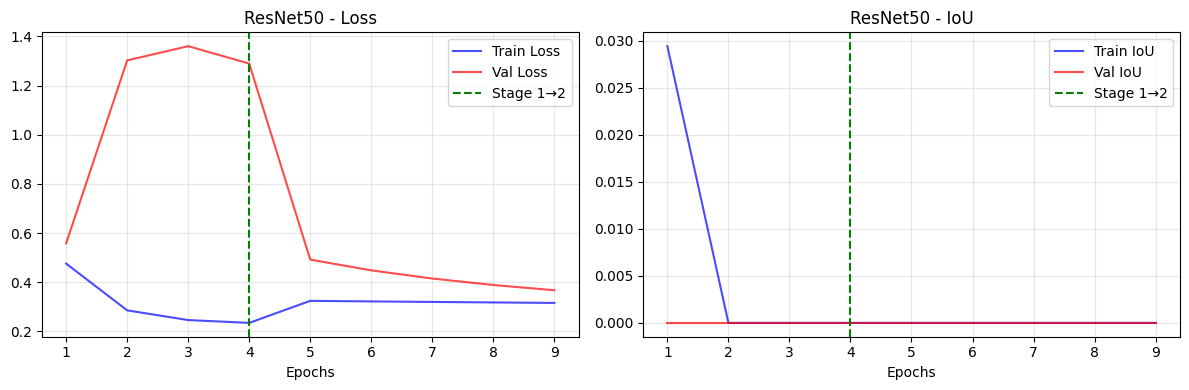

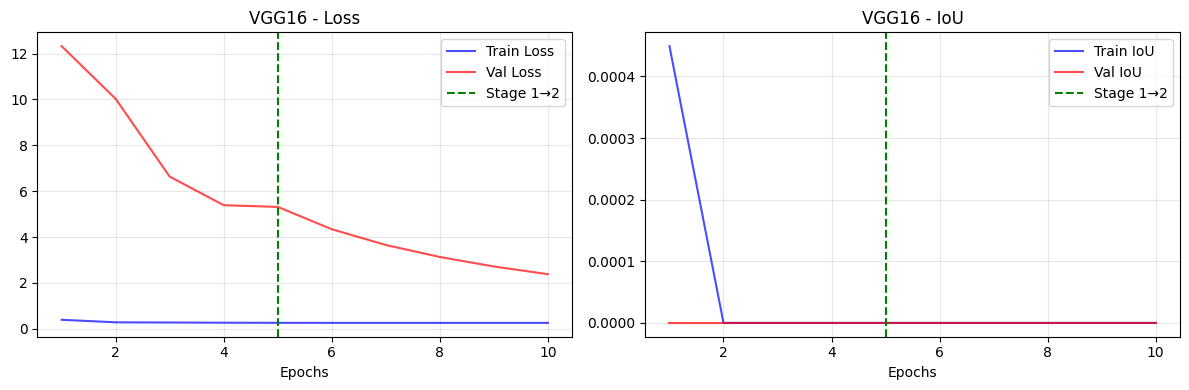

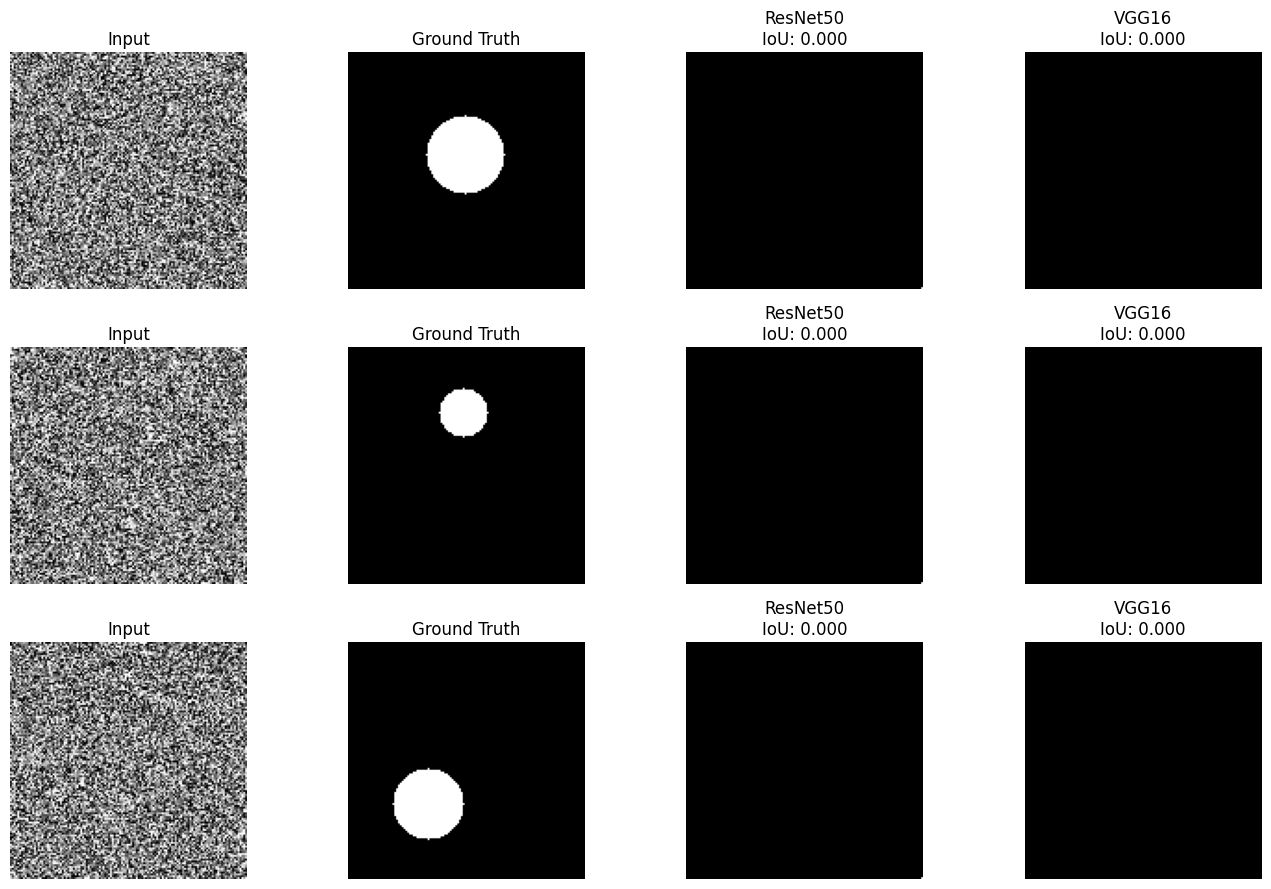


FALSE POSITIVE/NEGATIVE ANALYSIS

ResNet50 Analysis:
  TP: 0, FP: 30, FN: 45,358, TN: 446,132
  Precision: 0.0000, Recall: 0.0000, F1: 0.0000

VGG16 Analysis:
  TP: 0, FP: 0, FN: 45,358, TN: 446,162
  Precision: 0.0000, Recall: 0.0000, F1: 0.0000

FINAL SUMMARY: TRANSFER LEARNING COMPARISON

1️⃣ ENVIRONMENT:
   TensorFlow: 2.20.0
   Keras: 3.13.2

2️⃣ MODELS:
   ResNet50: 32,599,265 parameters
   VGG16: 18,639,009 parameters

3️⃣ TRAINING:
   Stage 1: 5 epochs (encoder frozen)
   Stage 2: 5 epochs (fine-tune)

4️⃣ TEST PERFORMANCE:
   Metric          ResNet50     VGG16       
   --------------- ------------ ------------
   IoU             0.0000       0.0000      
   Loss            0.4187       2.7510      

5️⃣ EFFICIENCY:
   ResNet50: 7.1 minutes
   VGG16: 16.3 minutes

6️⃣ WINNER:
   🏆 Better IoU: VGG16

7️⃣ DISCLAIMER:
   ⚠️  Fast training with reduced epochs and dataset
   ⚠️  Results are for demonstration only
   ⚠️  Not generalizable conclusions

✅ PROBLEM 3 COMPLETED SUCCESSF

In [30]:
"""
PROBLEM 3 - PART 3: Evaluation and Comparison
"""

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Re-use models, histories, test_data from Parts 1 & 2

def evaluate_model(model, model_name, test_dataset):
    """Evaluate model on test set."""
    print(f"\nEvaluating {model_name}...")
    results = model.evaluate(test_dataset, verbose=1)

    metrics = {
        'loss': results[0],
        'accuracy': results[1],
        'iou': results[2]
    }
    print(f"  Loss: {metrics['loss']:.4f}")
    print(f"  Accuracy: {metrics['accuracy']:.4f}")
    print(f"  IoU: {metrics['iou']:.4f}")
    return metrics

# 1. EVALUATE BOTH MODELS
print("\n" + "="*70)
print("EVALUATING MODELS")
print("="*70)

resnet_metrics = evaluate_model(resnet_model, "ResNet50", test_dataset)
vgg_metrics = evaluate_model(vgg_model, "VGG16", test_dataset)

# 2. COMPARISON TABLE
print("\n" + "="*70)
print("COMPARISON RESULTS")
print("="*70)

comparison_data = {
    'Metric': ['Test Loss', 'Test IoU', 'Test Accuracy', 'Training Time (min)', 'Parameters'],
    'ResNet50': [
        f"{resnet_metrics['loss']:.4f}",
        f"{resnet_metrics['iou']:.4f}",
        f"{resnet_metrics['accuracy']:.4f}",
        f"{resnet_time/60:.2f}",
        f"{resnet_model.count_params():,}"
    ],
    'VGG16': [
        f"{vgg_metrics['loss']:.4f}",
        f"{vgg_metrics['iou']:.4f}",
        f"{vgg_metrics['accuracy']:.4f}",
        f"{vgg_time/60:.2f}",
        f"{vgg_model.count_params():,}"
    ]
}

df = pd.DataFrame(comparison_data)
print(df.to_string(index=False))

print("\n" + "-"*70)
iou_winner = "ResNet50" if resnet_metrics['iou'] > vgg_metrics['iou'] else "VGG16"
time_winner = "VGG16" if vgg_time < resnet_time else "ResNet50"

print(f"🏆 Better IoU: {iou_winner} ({max(resnet_metrics['iou'], vgg_metrics['iou']):.4f})")
print(f"⚡ Faster training: {time_winner} ({min(resnet_time, vgg_time)/60:.1f} min)")
print("="*70)

# 3. PLOT TRAINING PROGRESS
def plot_training(history1, history2, model_name):
    """Plot training progress."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Combine histories
    all_loss = history1.history['loss'] + history2.history['loss']
    all_val_loss = history1.history['val_loss'] + history2.history['val_loss']
    all_iou = history1.history['foreground_iou'] + history2.history['foreground_iou']
    all_val_iou = history1.history['val_foreground_iou'] + history2.history['val_foreground_iou']
    epochs = range(1, len(all_loss) + 1)

    # Loss
    axes[0].plot(epochs, all_loss, 'b-', label='Train Loss', alpha=0.7)
    axes[0].plot(epochs, all_val_loss, 'r-', label='Val Loss', alpha=0.7)
    axes[0].axvline(x=len(history1.history['loss']), color='g', linestyle='--', label='Stage 1→2')
    axes[0].set_title(f'{model_name} - Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # IoU
    axes[1].plot(epochs, all_iou, 'b-', label='Train IoU', alpha=0.7)
    axes[1].plot(epochs, all_val_iou, 'r-', label='Val IoU', alpha=0.7)
    axes[1].axvline(x=len(history1.history['loss']), color='g', linestyle='--', label='Stage 1→2')
    axes[1].set_title(f'{model_name} - IoU')
    axes[1].set_xlabel('Epochs')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Plot both models
plot_training(resnet_history1, resnet_history2, "ResNet50")
plot_training(vgg_history1, vgg_history2, "VGG16")

# 4. VISUALIZE PREDICTIONS
def visualize_predictions(model1, model2, test_data, num_samples=3):
    """Visualize predictions."""
    x_test, y_test = test_data
    indices = np.random.choice(len(x_test), min(num_samples, len(x_test)), replace=False)

    preds1 = model1.predict(x_test[indices], verbose=0)
    preds2 = model2.predict(x_test[indices], verbose=0)

    fig, axes = plt.subplots(num_samples, 4, figsize=(14, 3*num_samples))

    for i, idx in enumerate(indices):
        axes[i, 0].imshow(x_test[idx].squeeze(), cmap='gray')
        axes[i, 0].set_title('Input')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(y_test[idx].squeeze(), cmap='gray')
        axes[i, 1].set_title('Ground Truth')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(preds1[i].squeeze() > 0.5, cmap='gray')
        iou1 = foreground_iou(y_test[idx], preds1[i]).numpy()
        axes[i, 2].set_title(f'ResNet50\nIoU: {iou1:.3f}')
        axes[i, 2].axis('off')

        axes[i, 3].imshow(preds2[i].squeeze() > 0.5, cmap='gray')
        iou2 = foreground_iou(y_test[idx], preds2[i]).numpy()
        axes[i, 3].set_title(f'VGG16\nIoU: {iou2:.3f}')
        axes[i, 3].axis('off')

    plt.tight_layout()
    plt.show()

visualize_predictions(resnet_model, vgg_model, test_data)

# 5. FALSE POSITIVE/NEGATIVE ANALYSIS
def analyze_predictions(model, model_name, test_data):
    """Analyze false positives and negatives."""
    x_test, y_test = test_data
    preds = model.predict(x_test, verbose=0)
    binary = (preds > 0.5).astype(np.float32)

    tp = np.sum((y_test == 1) & (binary == 1))
    fp = np.sum((y_test == 0) & (binary == 1))
    fn = np.sum((y_test == 1) & (binary == 0))
    tn = np.sum((y_test == 0) & (binary == 0))

    precision = tp / (tp + fp + 1e-7)
    recall = tp / (tp + fn + 1e-7)
    f1 = 2 * precision * recall / (precision + recall + 1e-7)

    print(f"\n{model_name} Analysis:")
    print(f"  TP: {tp:,}, FP: {fp:,}, FN: {fn:,}, TN: {tn:,}")
    print(f"  Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

    return {'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn, 'precision': precision, 'recall': recall, 'f1': f1}

print("\n" + "="*70)
print("FALSE POSITIVE/NEGATIVE ANALYSIS")
print("="*70)

resnet_analysis = analyze_predictions(resnet_model, "ResNet50", test_data)
vgg_analysis = analyze_predictions(vgg_model, "VGG16", test_data)

# 6. FINAL SUMMARY
print("\n" + "="*80)
print("FINAL SUMMARY: TRANSFER LEARNING COMPARISON")
print("="*80)

print("\n1️⃣ ENVIRONMENT:")
print(f"   TensorFlow: {tf.__version__}")
print(f"   Keras: {tf.keras.__version__}")

print("\n2️⃣ MODELS:")
print(f"   ResNet50: {resnet_model.count_params():,} parameters")
print(f"   VGG16: {vgg_model.count_params():,} parameters")

print("\n3️⃣ TRAINING:")
print(f"   Stage 1: {config['stage1_epochs']} epochs (encoder frozen)")
print(f"   Stage 2: {config['stage2_epochs']} epochs (fine-tune)")

print("\n4️⃣ TEST PERFORMANCE:")
print(f"   {'Metric':<15} {'ResNet50':<12} {'VGG16':<12}")
print(f"   {'-'*15:<15} {'-'*12:<12} {'-'*12:<12}")
print(f"   {'IoU':<15} {resnet_metrics['iou']:<12.4f} {vgg_metrics['iou']:<12.4f}")
print(f"   {'Loss':<15} {resnet_metrics['loss']:<12.4f} {vgg_metrics['loss']:<12.4f}")

print("\n5️⃣ EFFICIENCY:")
print(f"   ResNet50: {resnet_time/60:.1f} minutes")
print(f"   VGG16: {vgg_time/60:.1f} minutes")

print("\n6️⃣ WINNER:")
iou_winner = "ResNet50" if resnet_metrics['iou'] > vgg_metrics['iou'] else "VGG16"
print(f"   🏆 Better IoU: {iou_winner}")

print("\n7️⃣ DISCLAIMER:")
print("   ⚠️  Fast training with reduced epochs and dataset")
print("   ⚠️  Results are for demonstration only")
print("   ⚠️  Not generalizable conclusions")

print("\n" + "="*80)
print("✅ PROBLEM 3 COMPLETED SUCCESSFULLY!")
print("="*80)